# Principal Component Analysis (PCA) from Scratch

This notebook implements PCA from scratch using NumPy and Matplotlib.

## Mathematical Foundations
PCA project $D$-dimensional data onto a lower $d$-dimensional subspace while maximizing variance.
1. Center the data (subtract mean):
   $$X_{centered} = X - \mu$$
2. Compute the **Covariance Matrix** $\Sigma$:
   $$\Sigma = \frac{1}{m-1} X_{centered}^T X_{centered}$$
3. Compute eigenvalues $\lambda_i$ and eigenvectors $v_i$ of $\Sigma$:
   $$\Sigma v_i = \lambda_i v_i$$
4. Sort eigenvalues in descending order and select the top $d$ eigenvectors.
5. Project centered data onto top eigenvectors: $X_{projected} = X_{centered} W$.

In [5]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

## Generate 3D Correlated Data

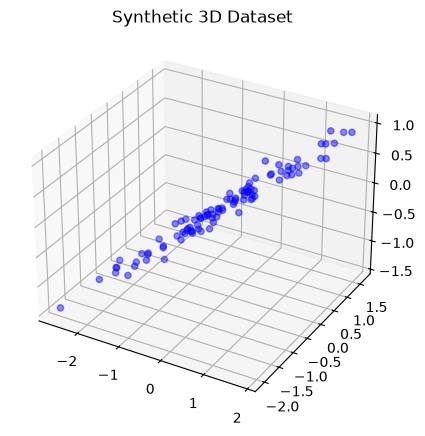

In [6]:
x1 = np.random.randn(100)
x2 = x1 * 0.8 + np.random.randn(100) * 0.2
x3 = x1 * 0.5 + np.random.randn(100) * 0.1
X = np.vstack([x1, x2, x3]).T

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:, 0], X[:, 1], X[:, 2], color='blue', alpha=0.7)
ax.set_title('Synthetic 3D Dataset')
plt.show()

## PCA Implementation

In [7]:
class PCAFromScratch:
    def __init__(self, n_components=2):
        self.n_components = n_components
        self.components = None
        self.mean = None
        
    def fit(self, X):
        # 1. Center the data
        self.mean = np.mean(X, axis=0)
        X_centered = X - self.mean
        
        # 2. Compute Covariance Matrix
        covariance_matrix = np.cov(X_centered.T)
        
        # 3. Compute Eigenvalues and Eigenvectors
        eigenvalues, eigenvectors = np.linalg.eig(covariance_matrix)
        eigenvalues = np.real(eigenvalues)
        eigenvectors = np.real(eigenvectors)
        
        # Transpose to sort rows of eigenvectors
        eigenvectors = eigenvectors.T
        
        # 4. Sort eigenvalues/eigenvectors in descending order
        idxs = np.argsort(eigenvalues)[::-1]
        eigenvalues = eigenvalues[idxs]
        eigenvectors = eigenvectors[idxs]
        
        # 5. Store components
        self.components = eigenvectors[:self.n_components]
        
    def transform(self, X):
        # Center the data and project
        X_centered = X - self.mean
        return np.dot(X_centered, self.components.T)

## Project from 3D to 2D & Plot Results

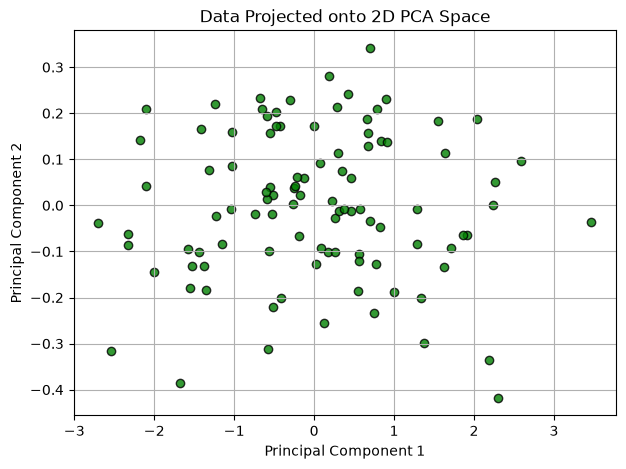

In [8]:
pca = PCAFromScratch(n_components=2)
pca.fit(X)
X_transformed = pca.transform(X)

plt.figure(figsize=(7, 5))
plt.scatter(X_transformed[:, 0], X_transformed[:, 1], color='green', alpha=0.8, edgecolors='k')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Data Projected onto 2D PCA Space')
plt.grid(True)
plt.show()